In [1]:
from __future__ import division
import json
%matplotlib inline
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
import itertools, operator
import csv
import os,glob
import datetime
import geopandas as gpd
from shapely import wkt
from scipy.stats import linregress, spearmanr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import math

import os, pandas as pd, geopandas as gpd
from shapely import wkt
from IPython.display import display

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, box

import osmnx as ox

import networkx as nx
import collections

from scipy.stats import gaussian_kde

from scipy.spatial import cKDTree

from IPython.display import display

import os
import sys

plt.rcParams["svg.fonttype"] = "none"

# INFORMATION

In [56]:
dates = ['_07_2022','_07_2023','_08_2022','_08_2023'] 

In [ ]:
DATE = '07_08_2022_2023'

# COLORS

In [4]:
colors_income = ['#FCBF49','#F77F00','#D62828'] #low, medium, high
colors_gender = ['#7209B7','#4CC9F0'] #fem, mal
colors_age = ['#BE95C4','#9F86C0','#5E548E','#231942'] #young->old

In [5]:
from matplotlib.colors import LinearSegmentedColormap
cmap_income = LinearSegmentedColormap.from_list('income', colors_income)
cmap_gender = LinearSegmentedColormap.from_list('gender', colors_gender)
cmap_age = LinearSegmentedColormap.from_list('age', colors_age)

# CITIES

In [60]:
cities = ['Madrid', 'Barcelona', 'Valencia', 'Zaragoza', 'Sevilla', 'Malaga', 'Murcia', 'Palma_de_Mallorca', 'Las_Palmas',
          'Alicante', 'Bilbao', 'Valladolid', 'Cordoba', 'Vigo', 'Gijon', 'Vitoria_Gasteiz', 'A_Coruna', 'Granada', 'Elche', 
          'Cartagena', 'Oviedo', 'Jerez_de_la_Frontera', 'Santa_Cruz_de_Tenerife']

# OPEN DISTRICTS DATA

In [7]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\dataframes')

gdfs = []
for d in dates:
    df = pd.read_csv(f'results_districts{d}_2.csv')

    if df['geometry'].dtype == object:
        df['geometry'] = df['geometry'].apply(wkt.loads)

    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:25830')
    gdfs.append(gdf)

    print(f'\n── District results {d} ─────────────────────────────')
    display(gdf[['city','ID','avg_T']].head())

results_districts = pd.concat(gdfs, ignore_index=True)

num_cols   = [c for c in results_districts.select_dtypes('number').columns
              if c not in ['x', 'y']]
group_cols = ['city', 'ID']

results_districts = (results_districts
                     .groupby(group_cols, as_index=False)
                     .agg({**{c: 'mean' for c in num_cols},
                           'geometry': 'first'}))

results_districts = gpd.GeoDataFrame(results_districts,
                                     geometry='geometry',
                                     crs='EPSG:25830')

cent = results_districts.geometry.centroid
results_districts['x'] = cent.x
results_districts['y'] = cent.y

results_districts = {c: g.copy() for c, g in results_districts.groupby('city')}


── District results _07_2023 ─────────────────────────────


,city,ID,avg_T
0,San_Sebastian,01001,32.397593
1,San_Sebastian,01002,28.320769
2,Santander,01004_AM,28.379978
3,San_Sebastian,01009_AM,29.939339
4,Santander,01010,29.488546



── District results _08_2023 ─────────────────────────────


,city,ID,avg_T
0,San_Sebastian,01001,36.241111
1,San_Sebastian,01002,31.783654
2,Santander,01004_AM,29.634416
3,San_Sebastian,01009_AM,33.968839
4,Santander,01010,31.623469


# DEFINE DOMAIN

In [62]:
cities_box = {
    'Madrid': "Madrid, Spain",
    'Barcelona': "Barcelona, Spain",
    'Zaragoza': "Zaragoza, Spain",
    'Bilbao': "Bilbao, Spain",
    'Sevilla': "Seville, Spain",
    'Valencia': "Valencia, Spain",
    'Valladolid': "Valladolid, Spain",
    'Cordoba': "Córdoba, Spain",
    'Murcia': "Murcia, Spain",
    'Malaga': "Málaga, Spain",
    'Palma_de_Mallorca': "Palma de Mallorca, Spain",
    'Alicante': "Alicante, Spain",
    'Vigo': "Vigo, Spain",
    'Gijon': "Gijón, Spain",
    'Oviedo': "Oviedo, Spain",
    'Granada': "Granada, Spain",
    'Cartagena': "Cartagena, Spain",
    'A_Coruna': "A Coruña, Spain",
    'Elche': "Elche, Spain",
    'Vitoria_Gasteiz': "Vitoria-Gasteiz, Spain",
    'Jerez_de_la_Frontera': "Jerez de la Frontera, Spain",
    'Las_Palmas': "Las Palmas de Gran Canaria, Spain",
    'Santa_Cruz_de_Tenerife': "Santa Cruz de Tenerife, Spain"
}
    
    
xmin, xmax, ymin, ymax = {}, {}, {}, {}
extended_bbox_dict = {}

for city_key, city_full in cities_box.items():
    try:
        gdf = ox.geocode_to_gdf(city_full)
        poly = gdf.geometry.iloc[0]
        
        metr = gdf.to_crs(epsg=32630)
        metr_poly = metr.geometry.iloc[0]
        
        area_km2 = metr_poly.area / 1e6
        
        # multiply by a buffer factor
        buffer_factor = 1.5
        radius_km = math.sqrt(area_km2 / math.pi) * buffer_factor
        
        centroid = poly.centroid
        dlat = radius_km / 111.32
        dlon = radius_km / (111.32 * math.cos(math.radians(centroid.y)))
        
        minx, miny, maxx, maxy = poly.bounds
        xmin[city_key] = minx - dlon
        xmax[city_key] = maxx + dlon
        ymin[city_key] = miny - dlat
        ymax[city_key] = maxy + dlat
        
        ext = box(xmin[city_key], ymin[city_key], xmax[city_key], ymax[city_key])
        ext_bbox_gdf = gpd.GeoDataFrame({'geometry': [ext]}, crs=gdf.crs)
        extended_bbox_dict[city_key] = ext

        fig, ax = plt.subplots(figsize=(10, 10))
        gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Admin Boundary')
        ext_bbox_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linestyle='--', linewidth=2, label='Extended Bounding Box (+5km)')
        ax.set_title(city_full)  # or use city_key if you prefer
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend()
        plt.show()
        
    except Exception as e:
        print(f"Error with {city_full}: {e}")

Processing Tarragona…


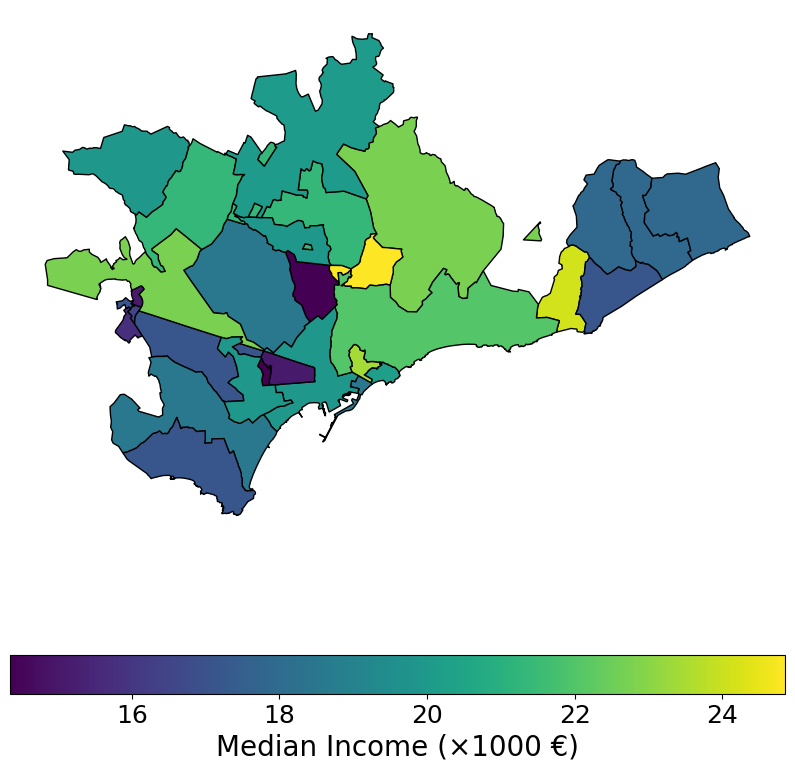

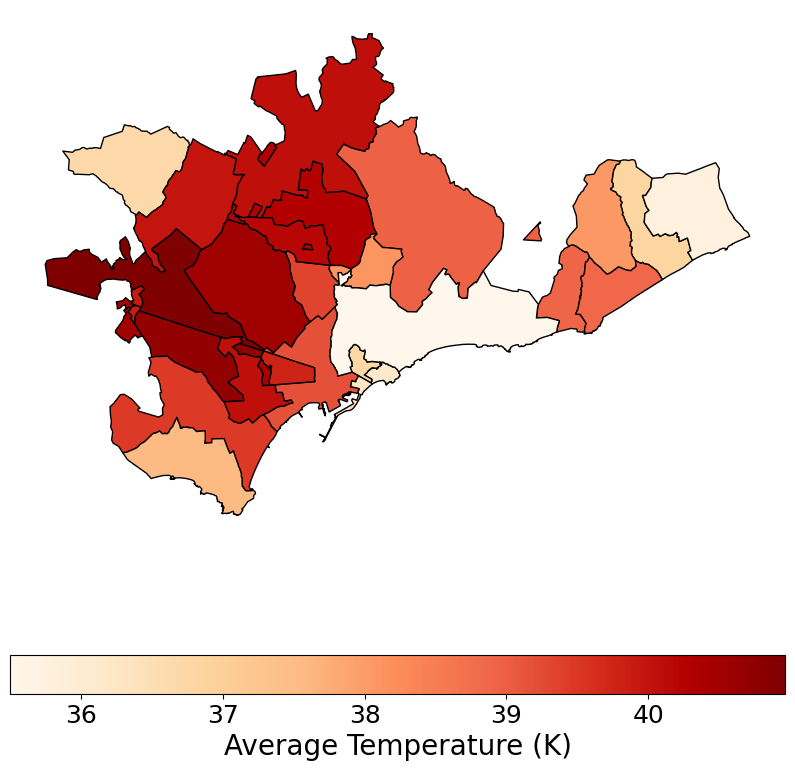

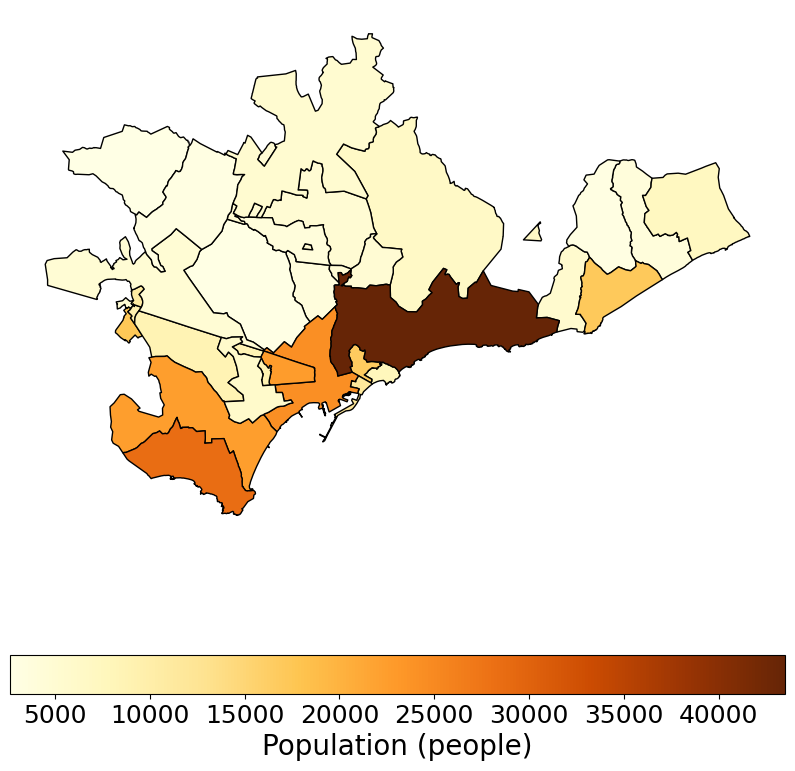

Processing Castellon…


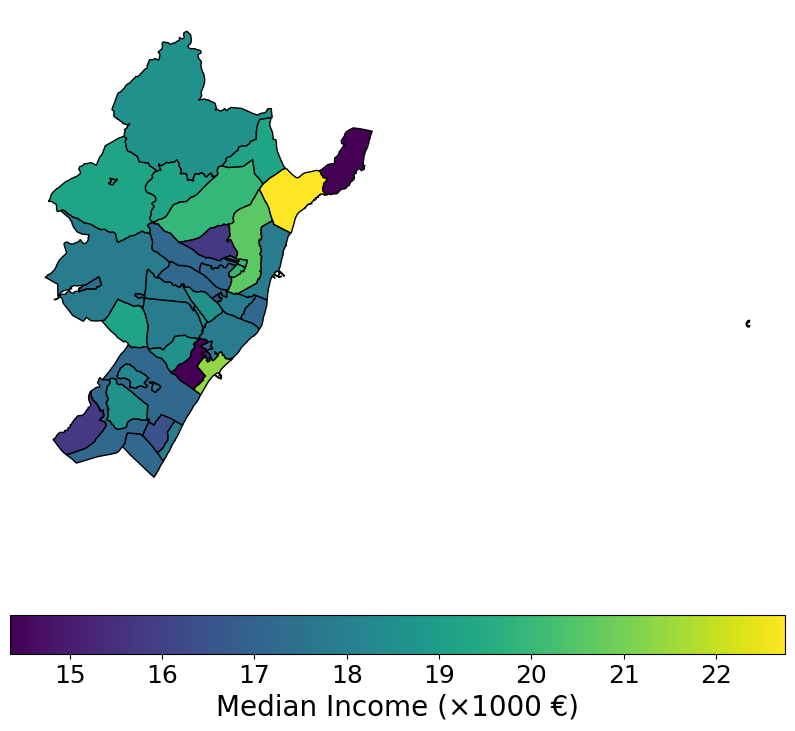

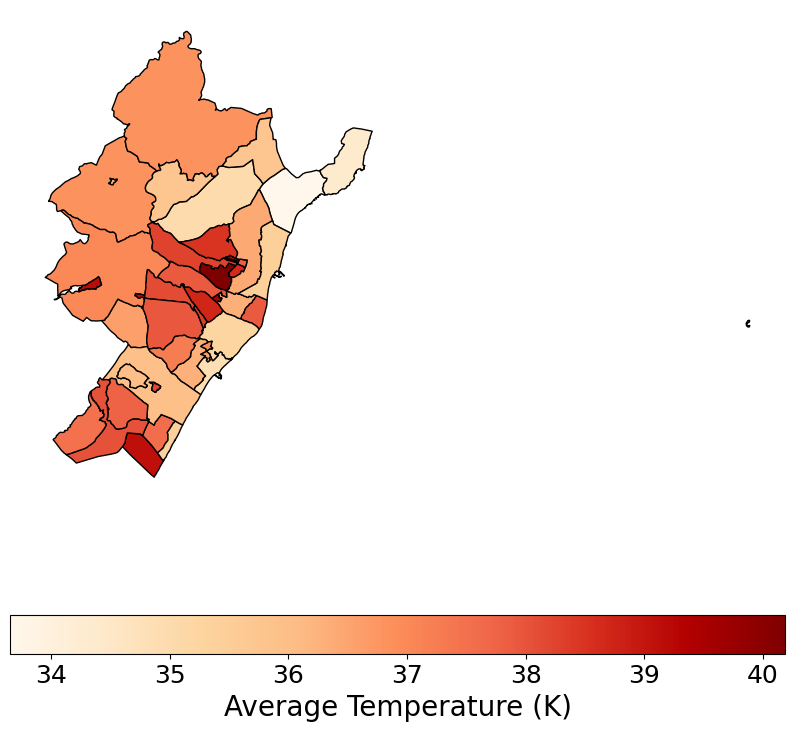

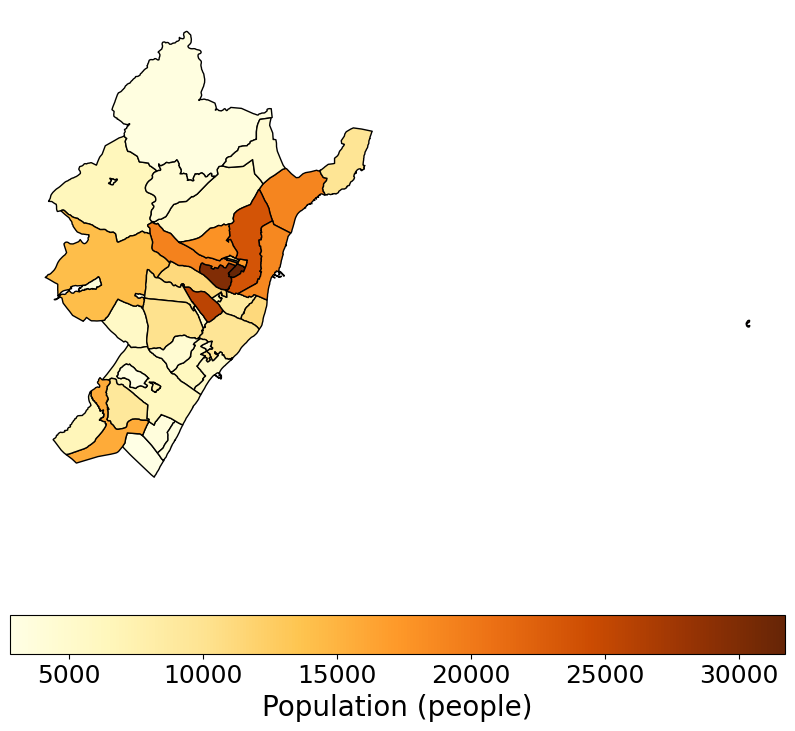

Processing Santander…


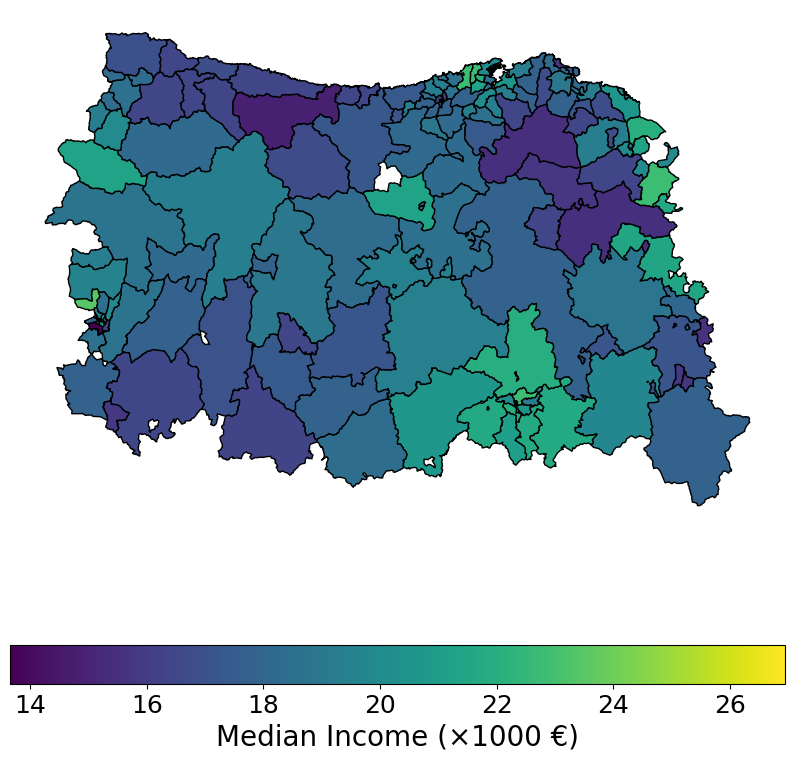

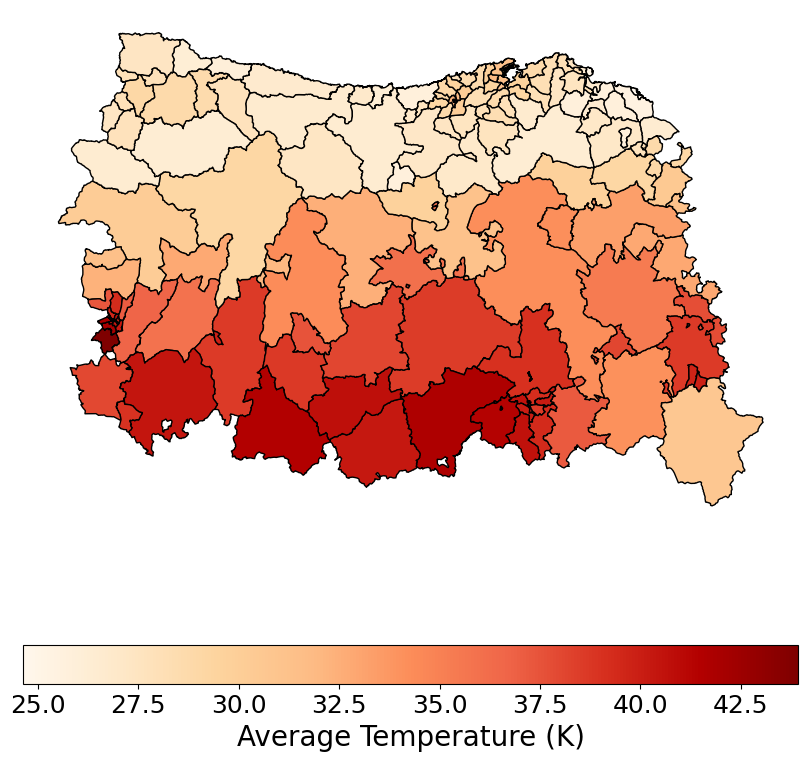

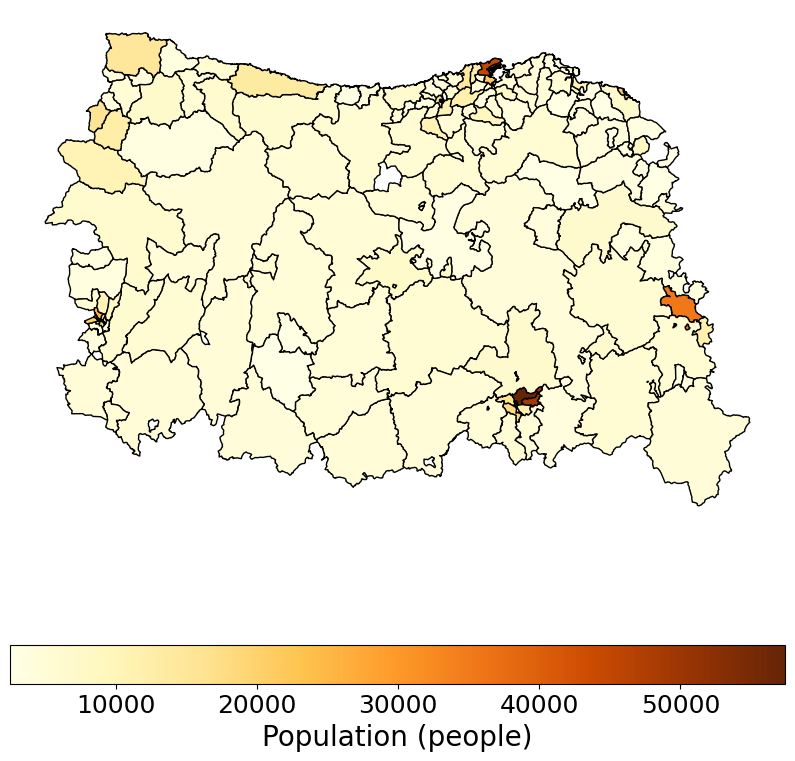

Processing Pamplona…


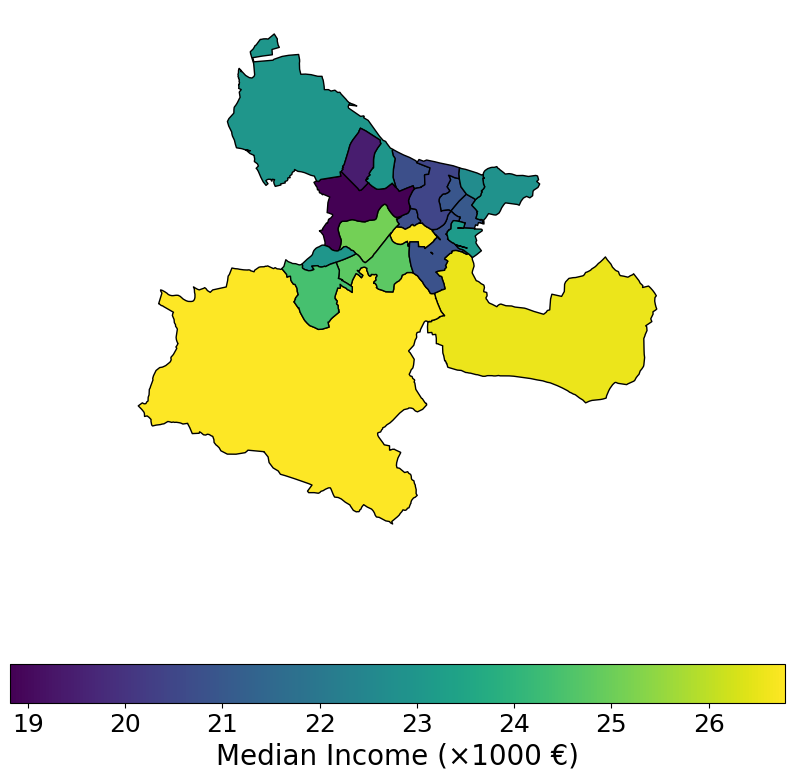

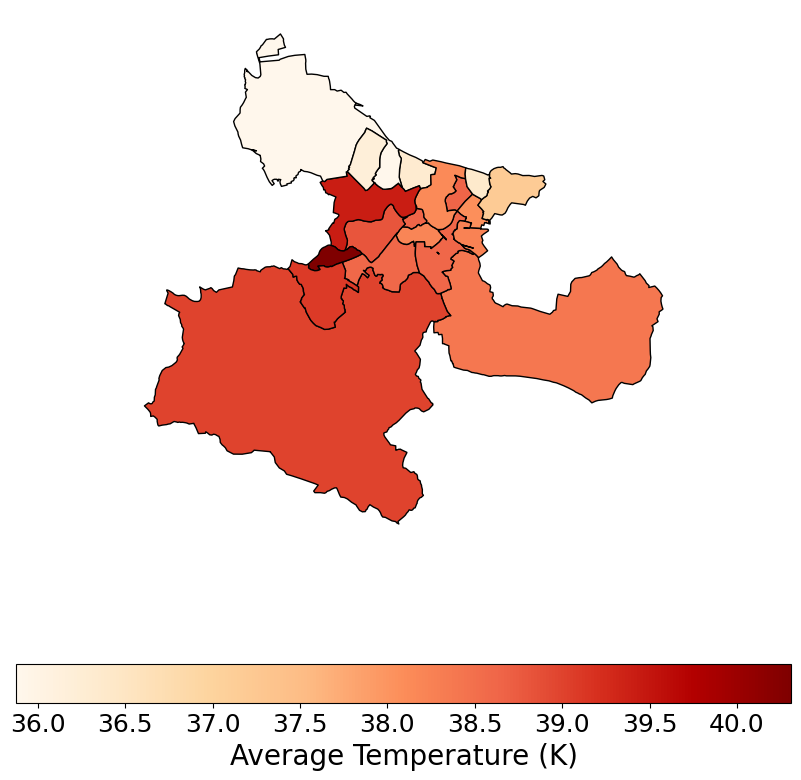

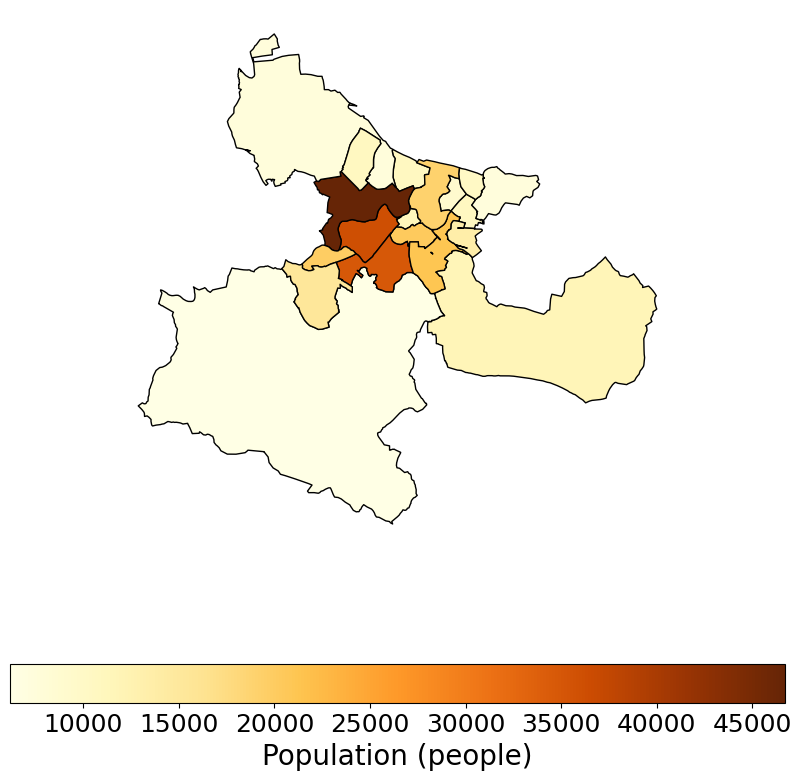

Processing Almeria…


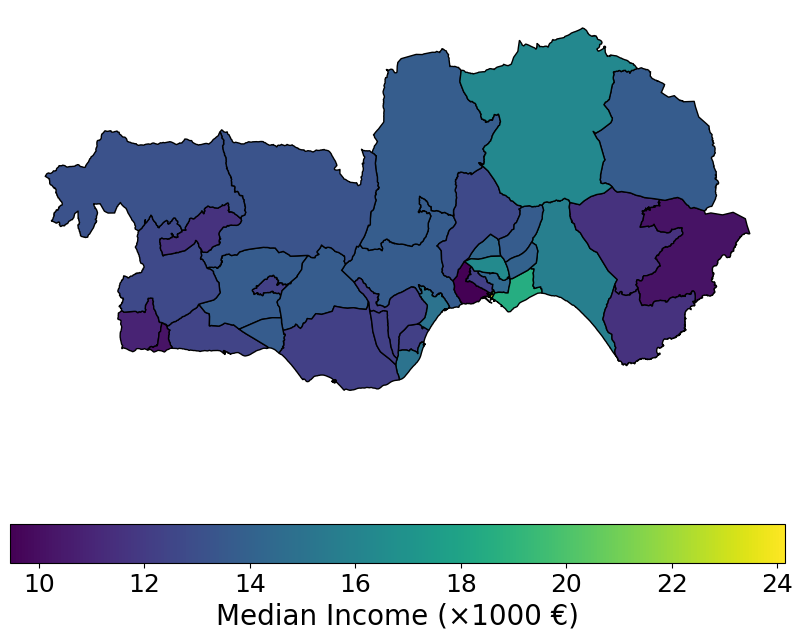

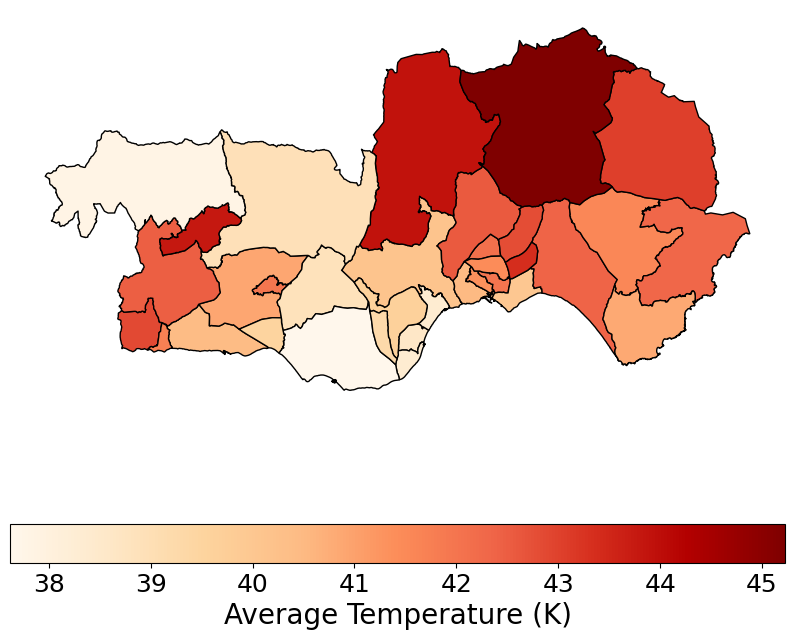

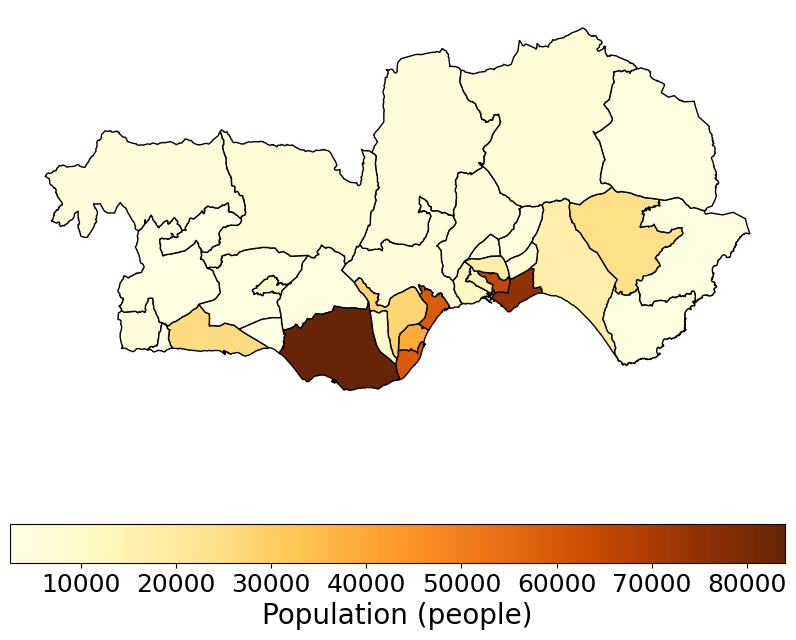

Processing San_Sebastian…


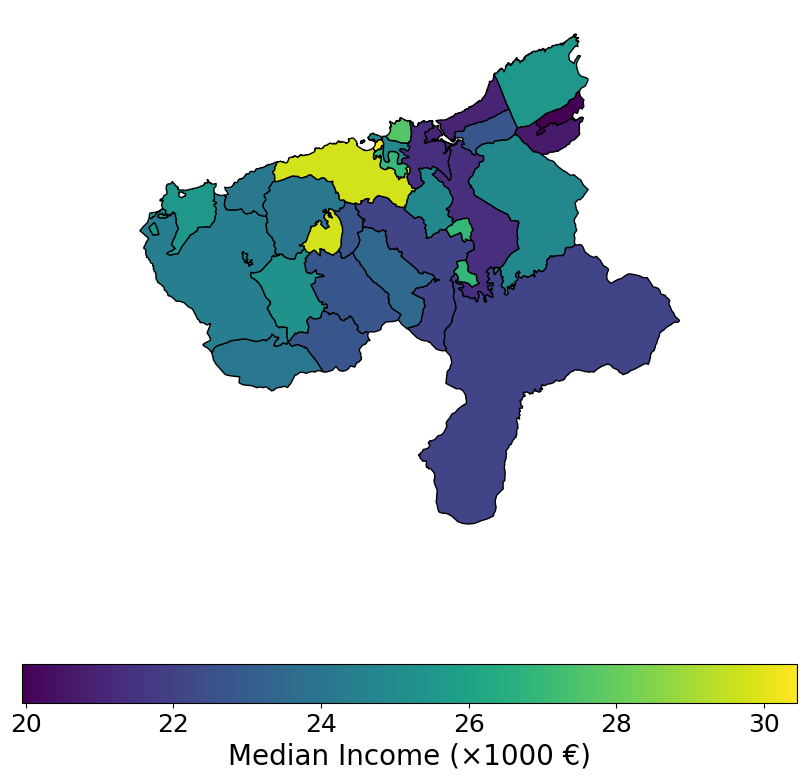

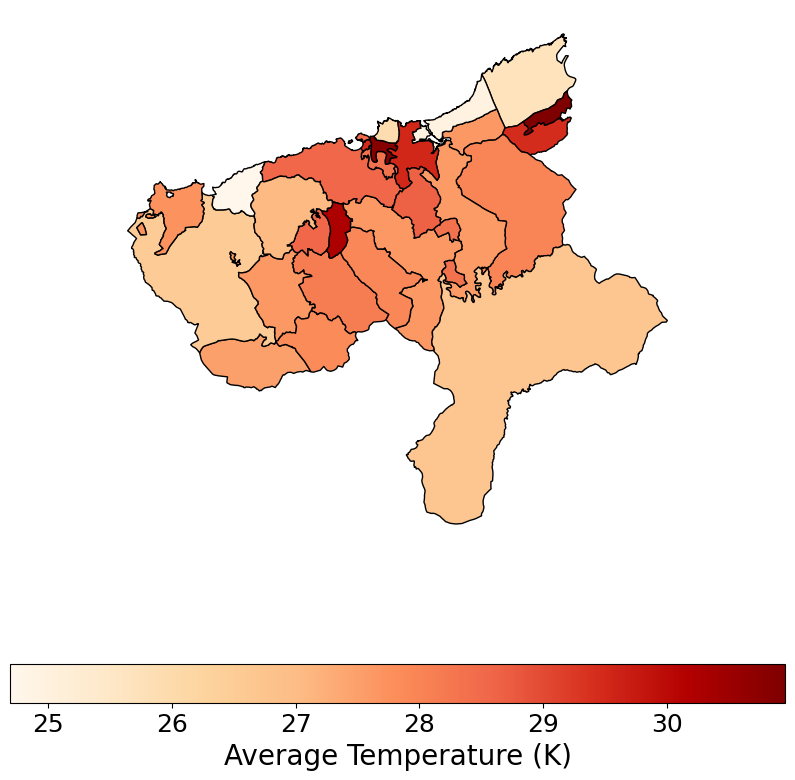

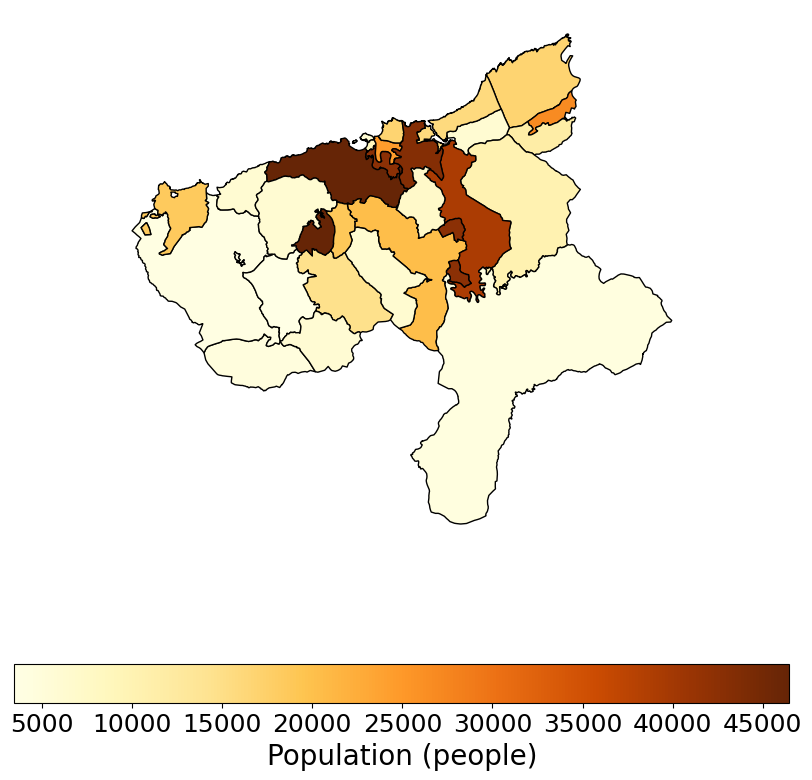

In [9]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2')

crs_trips = "EPSG:32630"
crs_ll    = "EPSG:4326"

bbox_utm_bounds = {}
for city, box_ll in extended_bbox_dict.items():
    box_utm = (
        gpd.GeoSeries([box_ll], crs=crs_ll)
           .to_crs(crs_trips)
           .iloc[0]
    )
    bbox_utm_bounds[city] = box_utm.bounds 


for city in cities:
    print(f"Processing {city}…")
    city_gdf = results_districts[city]        
    crs_metric = city_gdf.crs                  

    minx, miny, maxx, maxy = bbox_utm_bounds[city]

    mask = (
        city_gdf['x'].between(minx, maxx) &
        city_gdf['y'].between(miny, maxy)
    )
    city_filtered = city_gdf[mask].copy()
    if city_filtered.empty:
        print(f"  → No districts left inside bbox for {city}, skipping.")
        continue

    def plot_choro(gdf, column, cmap, title, units):
        fig, ax = plt.subplots(figsize=(10,10))
        gdf.plot(
            column=column, cmap=cmap, legend=True,
            ax=ax, edgecolor='black',
            legend_kwds={'label':f"{title} ({units})",'orientation':'horizontal'}
        )
        cbar = ax.get_figure().axes[-1]
        cbar.tick_params(labelsize=18)
        cbar.set_xlabel(f"{title} ({units})", fontsize=20)
        ax.set_axis_off()
        plt.show()

    plot_choro(city_filtered, 'median_revenue_per_consumption','viridis',
               'Median Income','×1000 €')
    plot_choro(city_filtered, 'avg_T','OrRd',
               'Average Temperature','K')
    plot_choro(city_filtered, 'population','YlOrBr',
               'Population','people')

In [10]:
# Clip results_districts to the city box
for city, ddf in results_districts.items():
    bb = bbox_utm_bounds.get(city)
    if bb is None:
        continue

    minx, miny, maxx, maxy = bb
    mask = ddf['x'].between(minx, maxx) & ddf['y'].between(miny, maxy)
    results_districts[city] = ddf.loc[mask].copy()
    print(f"{city}: kept {len(results_districts[city])} / {len(ddf)} districts inside bbox")

Almeria: kept 36 / 38 districts inside bbox
Castellon: kept 41 / 43 districts inside bbox
Pamplona: kept 19 / 44 districts inside bbox
San_Sebastian: kept 27 / 154 districts inside bbox
Santander: kept 166 / 169 districts inside bbox
Tarragona: kept 30 / 34 districts inside bbox


# OPEN MERGE DATA (mobility + districts)

In [11]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2\dataframes')

mobs = {}

for city in cities:

    df = pd.concat([
        pd.read_csv(f'{city}_mob_daily{d}.csv', dtype={'origen': str, 'destino': str})
          .assign(
              year  = int(d[-4:]),    
              month = int(d[1:3])      
          )
        for d in dates
    ], ignore_index=True)

    yearly_avg = df.groupby('year')['avg_T_origen'].mean()
    print(f"\nAverage origin temperature per year in {city}:")
    print(yearly_avg.to_string(), "\n")

    df['day']     = df['day'].astype(int)
    df['date']    = pd.to_datetime(df[['year','month','day']])
    df['weekday'] = df['date'].dt.weekday
    df = df.drop(columns=['year','month','day'])

    env_cols = [
        'avg_T_origen', 'median_income_per_consumption_origen','population_origen'
    ]
    env_month = (
        df
          .groupby([df['date'].dt.year, df['date'].dt.month, 'origen'], as_index=False)[env_cols]
          .mean()
          .rename(columns={
              'origen':       'district_id',
              'avg_T_origen': 'avg_T',
              'median_income_per_consumption_origen':'income',
              'population_origen':'population'
          })
    )
    env_mean = (
        env_month
          .groupby('district_id', as_index=False)
          .agg({
              'avg_T'     :'mean',
              'income'    :'mean',
              'population':'mean'
          })
    )

    df = (
        df
          .merge(env_mean, left_on='origen', right_on='district_id', how='left')
          .drop(columns=[
              'avg_T_origen', 'median_income_per_consumption_origen','population_origen',
              'district_id'
          ])
          .rename(columns={
              'avg_T'     : 'avg_T_origen',
              'income'    : 'median_income_per_consumption_origen',
              'population': 'population_origen'
          })
    )
    df = (
        df
          .merge(env_mean, left_on='destino', right_on='district_id', how='left')
          .drop(columns=[
              'avg_T','income','population','district_id'
          ])
          .rename(columns={
              'avg_T'     : 'avg_T_destino',
              'income'    : 'median_income_per_consumption_destino',
              'population': 'population_destino'
          })
    )

    key_cols = [
        'date','origen','destino','weekday',
        'actividad_origen','actividad_destino',
        'renta','edad'
    ]
    fixed_cols = [
        'avg_T_origen','median_income_per_consumption_origen','population_origen',
        'avg_T_destino','median_income_per_consumption_destino','population_destino',
        'distance','x_orig','y_orig','x_dest','y_dest'
    ]
    agg = {'viajes':'sum'}
    agg.update({c:'first' for c in fixed_cols})

    mobs[city] = df.groupby(key_cols, as_index=False).agg(agg)
    print(f"{city}: {len(mobs[city]):,} filas  |  flows tot = {mobs[city]['viajes'].sum():,}")


Average origin temperature per year in Tarragona:
year
2023    38.756131 



C:\Users\mduran\AppData\Local\Temp\ipykernel_9372\633597974.py:31: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


Tarragona: 1,443,078 filas  |  flows tot = 84,828,402.96200004

Average origin temperature per year in Castellon:
year
2023    37.222707 



C:\Users\mduran\AppData\Local\Temp\ipykernel_9372\633597974.py:31: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


Castellon: 1,540,197 filas  |  flows tot = 97,687,744.29200001

Average origin temperature per year in Santander:
year
2023    32.538698 



...

Pamplona: 1,637,462 filas  |  flows tot = 131,225,635.88599996

Average origin temperature per year in Almeria:
year
2023    40.573564 



C:\Users\mduran\AppData\Local\Temp\ipykernel_9372\633597974.py:31: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


Almeria: 1,278,524 filas  |  flows tot = 171,111,162.88599995

Average origin temperature per year in San_Sebastian:
year
2023    30.356606 



C:\Users\mduran\AppData\Local\Temp\ipykernel_9372\633597974.py:31: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .mean()


San_Sebastian: 7,639,408 filas  |  flows tot = 442,461,050.19800043


In [12]:
def mem_MB(df):
    return df.memory_usage(deep=True).sum() / 1_048_576

cat_cols   = ['origen','destino',
              'actividad_origen','actividad_destino',
              'renta','edad']

float_cols = ['avg_T_origen','avg_T_destino',
              'population_origen','population_destino',
              'distance','x_orig','y_orig','x_dest','y_dest']

for city, df in mobs.items():
    print(f'\n{city}  — before : {mem_MB(df):,.1f} MB')

    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    for col in float_cols:
        if col in df.columns:
            df[col] = df[col].astype('float32')           

    mobs[city] = df

    print(f'{city}  — after  : {mem_MB(df):,.1f} MB')


Tarragona  — before : 612.3 MB
Tarragona  — after  : 107.4 MB

Castellon  — before : 653.3 MB
Castellon  — after  : 114.6 MB

Santander  — before : 2,085.4 MB
Santander  — after  : 374.4 MB

Pamplona  — before : 693.9 MB
Pamplona  — after  : 121.8 MB

Almeria  — before : 541.5 MB
Almeria  — after  : 95.1 MB

San_Sebastian  — before : 3,232.0 MB
San_Sebastian  — after  : 582.9 MB


In [13]:
crs_trips = "EPSG:32630" 
crs_ll    = "EPSG:4326" 

bbox_utm_bounds = {}
for city in mobs:
    poly_ll = Polygon([
        (xmin[city], ymin[city]),
        (xmin[city], ymax[city]),
        (xmax[city], ymax[city]),
        (xmax[city], ymin[city]),
    ])
    poly_utm = (
        gpd.GeoSeries([poly_ll], crs=crs_ll)
           .to_crs(crs_trips)
           .iloc[0]
    )
    bbox_utm_bounds[city] = poly_utm.bounds

for city, df in mobs.items():
    
    minx, miny, maxx, maxy = bbox_utm_bounds[city]
    origen_utm = df['x_orig'].between(minx, maxx) & df['y_orig'].between(miny, maxy)
    destino_utm = df['x_dest'].between(minx, maxx) & df['y_dest'].between(miny, maxy)
    print(f"{city} (UTM):   origen_dentro={origen_utm.sum()}, destino_dentro={destino_utm.sum()}")
    mask_both = origen_utm & destino_utm
    print(f"{city}: viajes_con_ambos_dentro={mask_both.sum()} / total={len(df)}\n")

    mobs[city] = df[mask_both].copy()

Tarragona (UTM):   origen_dentro=1291223, destino_dentro=1291297
Tarragona: viajes_con_ambos_dentro=1166765 / total=1443078

Castellon (UTM):   origen_dentro=1508823, destino_dentro=1508421
Castellon: viajes_con_ambos_dentro=1479901 / total=1540197

Santander (UTM):   origen_dentro=4811832, destino_dentro=4812767
Santander: viajes_con_ambos_dentro=4743053 / total=4907060

Pamplona (UTM):   origen_dentro=932144, destino_dentro=932746
Pamplona: viajes_con_ambos_dentro=813645 / total=1637462

Almeria (UTM):   origen_dentro=1261527, destino_dentro=1261340
Almeria: viajes_con_ambos_dentro=1250935 / total=1278524

San_Sebastian (UTM):   origen_dentro=1419056, destino_dentro=1417930
San_Sebastian: viajes_con_ambos_dentro=1220892 / total=7639408



In [14]:
district_counts = {
    city: df['origen'].nunique()
    for city, df in mobs.items()
}

district_counts_df = (
    pd.DataFrame.from_dict(district_counts, orient='index', columns=['num_districts'])
      .reset_index()
      .rename(columns={'index': 'city'})
)

print(district_counts_df)

            city  num_districts
0      Tarragona             30
1      Castellon             41
2      Santander            159
3       Pamplona             19
4        Almeria             36
5  San_Sebastian             27


In [15]:
for city, df in mobs.items():
    mask = (
        (df['actividad_destino'] != 'casa')
        )
    mobs[city] = df.loc[mask]

In [16]:
mobs[city]

,date,origen,destino,weekday,actividad_origen,actividad_destino,renta,edad,viajes,avg_T_origen,median_income_per_consumption_origen,population_origen,avg_T_destino,median_income_per_consumption_destino,population_destino,distance,x_orig,y_orig,x_dest,y_dest
9887,2023-07-01,20009,20009,5,casa,frecuente,10-15,0-25,520.366,28.141666,22.75000,14631.0,28.560972,22.75000,14631.0,0.0,580146.7500,4785278.0,580146.7500,4785278.0
9888,2023-07-01,20009,20009,5,casa,frecuente,10-15,25-45,663.182,28.141666,22.75000,14631.0,28.560972,22.75000,14631.0,0.0,580146.7500,4785278.0,580146.7500,4785278.0
9889,2023-07-01,20009,20009,5,casa,frecuente,10-15,45-65,952.432,28.141666,22.75000,14631.0,28.560972,22.75000,14631.0,0.0,580146.7500,4785278.0,580146.7500,4785278.0
9890,2023-07-01,20009,20009,5,casa,frecuente,10-15,65-100,794.038,28.141666,22.75000,14631.0,28.560972,22.75000,14631.0,0.0,580146.7500,4785278.0,580146.7500,4785278.0
9891,2023-07-01,20009,20009,5,casa,no_frecuente,10-15,0-25,53.894,28.141666,22.75000,14631.0,28.560972,22.75000,14631.0,0.0,580146.7500,4785278.0,580146.7500,4785278.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7550284,2023-08-31,31149_AM,31149_AM,3,no_frecuente,frecuente,>15,0-25,20.924,26.681128,22.07575,4418.0,26.801760,22.07575,4418.0,0.0,594392.3125,4779692.5,594392.3125,4779692.5
7550285,2023-08-31,31149_AM,31149_AM,3,no_frecuente,no_frecuente,10-15,0-25,4.874,26.681128,22.07575,4418.0,26.801760,22.07575,4418.0,0.0,594392.3125,4779692.5,594392.3125,4779692.5
7550286,2023-08-31,31149_AM,31149_AM,3,no_frecuente,trabajo_estudio,>15,45-65,8.444,26.681128,22.07575,4418.0,26.801760,22.07575,4418.0,0.0,594392.3125,4779692.5,594392.3125,4779692.5
7550287,2023-08-31,31149_AM,31149_AM,3,trabajo_estudio,frecuente,>15,25-45,10.036,26.681128,22.07575,4418.0,26.801760,22.07575,4418.0,0.0,594392.3125,4779692.5,594392.3125,4779692.5


# SEGREGATION METRICS

In [17]:
os.chdir(r'C:\Users\mduran\Desktop\PhD\PROJECT 2')

def rho_assortativity(X_normalized):
    """
    Calculates the Pearson-correlation-based assortativity from a normalized matrix,
    whose row/col correspond to bin labels in [1..n_bins].
    """
    if X_normalized.size == 0 or np.nansum(X_normalized) == 0:
        return np.nan

    n_rows, n_cols = X_normalized.shape
    row_vals = np.arange(1, n_rows+1)  # e.g. 1..5 if n_bins=5
    col_vals = np.arange(1, n_cols+1)

    # sum_{i,j}( i*j*X_ij )
    sum_ij = 0.0
    for i in range(n_rows):
        for j in range(n_cols):
            sum_ij += row_vals[i] * col_vals[j] * X_normalized[i,j]

    # sum_i, sum_j
    sum_i = 0.0
    for i in range(n_rows):
        sum_i += row_vals[i] * np.sum(X_normalized[i,:])
    sum_j = 0.0
    for j in range(n_cols):
        sum_j += col_vals[j] * np.sum(X_normalized[:,j])

    numerator = sum_ij - (sum_i * sum_j)

    # denominator
    sum_i2 = 0.0
    for i in range(n_rows):
        sum_i2 += (row_vals[i]**2) * np.sum(X_normalized[i,:])
    sum_j2 = 0.0
    for j in range(n_cols):
        sum_j2 += (col_vals[j]**2) * np.sum(X_normalized[:,j])

    denom = np.sqrt(sum_i2 - sum_i**2) * np.sqrt(sum_j2 - sum_j**2)
    if denom == 0:
        return np.nan
    return round(numerator / denom, 3)

def total_exposure(X):
    """
    E = (sum_{i,j}(X_ij * j)) / (sum_{i,j}(X_ij)),
    where j in [1..n_bins] are the columns (destination bins).
    """
    total = X.values.sum()
    if total == 0:
        return np.nan

    weighted_sum = 0.0
    for j_bin in X.columns:  
        weighted_sum += j_bin * X[j_bin].sum()
    return round(weighted_sum / total, 3)

def exposure_directional_index(X_normalized):
    """
    R = (X_upper - X_lower)/(X_upper + X_lower),
    where X_upper = sum of X_ij for j>i, X_lower = sum of X_ij for j<i.
    X_norm is normalized so sum(X_norm)=1, with row/col in [1..n_bins].
    """
    if X_normalized.values.sum() == 0:
        return np.nan

    upper = 0.0
    lower = 0.0
    row_bins = X_normalized.index
    col_bins = X_normalized.columns

    for i_idx, i_bin in enumerate(row_bins):
        for j_idx, j_bin in enumerate(col_bins):
            val = X_normalized.iloc[i_idx, j_idx]
            if j_bin > i_bin:
                upper += val
            elif j_bin < i_bin:
                lower += val

    denom = upper + lower
    if denom == 0:
        return np.nan
    return round((upper - lower) / denom, 3)

def exposure_directional_index_row(X):
    """
    Compute the directional index R on a row-normalized basis.
    
    For each row i (representing an origin), normalize the row so that:
        p_ij = X[i, j] / sum_j X[i, j]
    Then, compute for each row:
        R_i = (sum_{j > i} p_ij - sum_{j < i} p_ij) / (sum_{j > i} p_ij + sum_{j < i} p_ij)
    Finally, return the average R across all rows that have trips.
    
    Parameters:
        X : pandas.DataFrame
            The OD matrix (raw trip counts) with rows and columns ordered 
            such that lower triangle corresponds to destinations with higher levels 
            (e.g., risk or income) compared to the origin.
    
    Returns:
        float
            The average directional index R (rounded to 3 decimals). Returns np.nan if no row contains trips.
    """
    r_values = []
    for i_idx, i_bin in enumerate(X.index):
        row_total = X.iloc[i_idx, :].sum()
        if row_total == 0:
            continue  # skip rows with no trips
        # Normalize the row
        p_row = X.iloc[i_idx, :] / row_total
        upper = 0.0
        lower = 0.0
        for j_idx, j_bin in enumerate(X.columns):
            if j_bin > i_bin:
                upper += p_row.iloc[j_idx]
            elif j_bin < i_bin:
                lower += p_row.iloc[j_idx]
        denom = upper + lower
        if denom == 0:
            continue
        r_values.append((upper - lower) / denom)
    
    if len(r_values) == 0:
        return np.nan
    return round(np.mean(r_values), 3)


# MONTHLY

In [18]:
#aggregated metrics
time = False

for city in cities:
    mobs[city] = mobs[city].groupby([
    'origen', 'destino', 'actividad_origen', 'actividad_destino', 'renta', 'edad']).viajes.sum().reset_index()

C:\Users\mduran\AppData\Local\Temp\ipykernel_9372\1012560872.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mobs[city] = mobs[city].groupby([
C:\Users\mduran\AppData\Local\Temp\ipykernel_9372\1012560872.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mobs[city] = mobs[city].groupby([
C:\Users\mduran\AppData\Local\Temp\ipykernel_9372\1012560872.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mobs[city] = mobs

In [19]:
mobs[city]

,origen,destino,actividad_origen,actividad_destino,renta,edad,viajes
0,01001,01001,casa,casa,10-15,0-25,0.0
1,01001,01001,casa,casa,10-15,25-45,0.0
2,01001,01001,casa,casa,10-15,45-65,0.0
3,01001,01001,casa,casa,10-15,65-100,0.0
4,01001,01001,casa,casa,<10,0-25,0.0
...,...,...,...,...,...,...,...
4435963,48912_AM,48912_AM,trabajo_estudio,trabajo_estudio,<10,65-100,0.0
4435964,48912_AM,48912_AM,trabajo_estudio,trabajo_estudio,>15,0-25,0.0
4435965,48912_AM,48912_AM,trabajo_estudio,trabajo_estudio,>15,25-45,0.0
4435966,48912_AM,48912_AM,trabajo_estudio,trabajo_estudio,>15,45-65,0.0


# BINNING DECILES

In [20]:
n_bins = 10

for city, df in results_districts.items():

    if {'Tbin','Popbin'}.issubset(df.columns):
        continue

    df = df.copy()                                     
    df['Tbin']   = pd.qcut(df['avg_T'],      q=n_bins,
                           labels=False).astype('Int8') + 1
    df['Popbin'] = pd.qcut(df['population'], q=n_bins,
                           labels=False).astype('Int8') + 1

    results_districts[city] = df

In [21]:
results_districts

{'Almeria':        city        ID      avg_T  median_revenue_per_consumption  population  \
 0   Almeria     04003  40.432659                       12.390000     25501.0   
 1   Almeria  04011_AM  40.132572                       13.650000      5309.0   
 2   Almeria   0401301  40.706920                       13.650000      3267.0   
 3   Almeria   0401302  40.145000                       24.150000      6388.0   
 4   Almeria   0401303  40.486288                        9.450000     11353.0   
 5   Almeria   0401304  40.795502                       19.950000      6967.0   
 6   Almeria   0401305  41.335385                       12.250000     14337.0   
 7   Almeria   0401306  41.996471                       14.350000     65838.0   
 8   Almeria   0401307  40.004276                       18.550000     75276.0   
 9   Almeria   0401308  42.374644                       15.750000     17327.0   
 10  Almeria     04024  42.128553                       14.350000      4526.0   
 11  Almeria   04

## INCOME

In [22]:
from matplotlib.colors import LogNorm

income_groups = ['<10', '10-15', '>15']
all_bins      = list(range(1, n_bins+1))

title_fs     = 30
label_fs     = 28
ticklabel_fs = 26

X_T_all = {
    inc: pd.DataFrame(
        0,
        index=all_bins,
        columns=all_bins,
        dtype=float
    )
    for inc in income_groups
}

results = []

for city in cities:
    print(f"\n{'='*34}\nProcessing {city}")

    vmax = 0

    # Bin‐mappers
    ddf      = results_districts[city]
    mapper_T = ddf.set_index('ID')['Tbin'].to_dict()
    
    df_city = mobs[city].copy()
    for col_o, col_d, mapper in [
        ('Tbin_origin',   'Tbin_dest',   mapper_T)
    ]:
        if col_o not in df_city.columns:
            df_city[col_o] = df_city['origen'].map(mapper).astype('Int8')
        if col_d not in df_city.columns:
            df_city[col_d] = df_city['destino'].map(mapper).astype('Int8')

    fig, axes = plt.subplots(
        1, len(income_groups),
        figsize=(5 * len(income_groups), 5),
        sharex=False, sharey=False
    )
    axes = np.atleast_1d(axes)

    for j, inc in enumerate(income_groups):
        df_inc = df_city[df_city['renta'] == inc]

        # build raw OD counts
        grouped = (df_inc
                   .groupby(['Tbin_origin','Tbin_dest'])['viajes']
                   .sum().reset_index())
        X_T = (grouped
               .pivot(index='Tbin_origin', columns='Tbin_dest', values='viajes')
               .fillna(0)
               .reindex(index=all_bins, columns=all_bins, fill_value=0))

        # total‐normalize
        total    = X_T.values.sum()
        X_T_norm = X_T / total if total else X_T

        vmax = max(vmax, X_T.values.max())

    for j, inc in enumerate(income_groups):
        df_inc = df_city[df_city['renta'] == inc]

        grouped = (df_inc
                   .groupby(['Tbin_origin','Tbin_dest'])['viajes']
                   .sum().reset_index())
        X_T = (grouped
               .pivot(index='Tbin_origin', columns='Tbin_dest', values='viajes')
               .fillna(0)
               .reindex(index=all_bins, columns=all_bins, fill_value=0))

        X_T_all[inc] += X_T

        total    = X_T.values.sum()
        X_T_norm = X_T / total if total else X_T

        rho_T    = rho_assortativity(X_T_norm.values)
        E_T      = total_exposure(X_T)
        R_T      = exposure_directional_index(X_T)
        R_T_row  = exposure_directional_index_row(X_T)
        results.append({
            'city': city, 'income': inc,
            'rho_T': rho_T, 'E_T': E_T,
            'R_T': R_T, 'R_T_row': R_T_row
        })
   
        X_plot = X_T.copy()
        positive_vals = X_plot.values[X_plot.values > 0]
        
        if len(positive_vals) > 0:
            vmin_log = positive_vals.min()
        else:
            vmin_log = 1.0
        
        im = axes[j].imshow(
            X_plot.T,
            origin='lower',
            aspect='auto',
            cmap='YlOrBr_r',
            norm=LogNorm(vmin=vmin_log, vmax=vmax))

        axes[j].set_title(inc, fontsize=title_fs)
        axes[j].set_xlabel("Origin decile", fontsize=label_fs)
        axes[j].set_xticks(np.arange(n_bins))
        axes[j].set_xticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
        axes[j].tick_params(axis='x', labelbottom=True, labelsize=ticklabel_fs)

        if j == 0:
            axes[j].set_ylabel("Destination decile", fontsize=label_fs)
            axes[j].set_yticks(np.arange(n_bins))
            axes[j].set_yticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
            axes[j].tick_params(axis='y', labelleft=True, labelsize=ticklabel_fs)
        else:
            axes[j].set_ylabel("")
            axes[j].set_yticks([])
            axes[j].set_yticklabels([])
            axes[j].tick_params(axis='y', left=False, labelleft=False)

    fig.subplots_adjust(wspace=0.1, right=0.88)
    cbar = fig.colorbar(
        im, ax=axes.tolist(),
        orientation='vertical',
        fraction=0.02, pad=0.055
    )
    cbar.ax.tick_params(labelsize=ticklabel_fs)
    cbar.set_label("Number of trips", fontsize=label_fs)
    cbar.ax.yaxis.get_offset_text().set_fontsize(21)

    if city in ['Madrid']:
        fig.savefig(f'{city}_OD_income_T_total_{DATE}.svg',
                dpi=600, bbox_inches='tight')
        plt.show(fig)
    plt.close(fig)


    fig2, axes2 = plt.subplots(
        1, len(income_groups),
        figsize=(5 * len(income_groups), 5),
        sharex=False, sharey=False
    )
    axes2 = np.atleast_1d(axes2)

    for j, inc in enumerate(income_groups):
        df_inc = df_city[df_city['renta'] == inc]

        grouped = (df_inc
                   .groupby(['Tbin_origin','Tbin_dest'])['viajes']
                   .sum().reset_index())
        X_T = (grouped
               .pivot(index='Tbin_origin', columns='Tbin_dest', values='viajes')
               .fillna(0)
               .reindex(index=all_bins, columns=all_bins, fill_value=0))

        row_sums = X_T.sum(axis=1).replace(0, 1)
        X_T_row  = X_T.div(row_sums, axis=0)

        im2 = axes2[j].imshow(
            X_T_row.T,
            origin='lower', aspect='auto',
            cmap='YlOrBr_r', vmin=0, vmax=1.0
        )
        axes2[j].set_title(inc, fontsize=title_fs)
        axes2[j].set_xlabel("Origin decile", fontsize=label_fs)
        axes2[j].set_xticks(np.arange(n_bins))
        axes2[j].set_xticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
        axes2[j].tick_params(axis='x', labelbottom=True, labelsize=ticklabel_fs)

        if j == 0:
            axes2[j].set_ylabel("Destination decile", fontsize=label_fs)
            axes2[j].set_yticks(np.arange(n_bins))
            axes2[j].set_yticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
            axes2[j].tick_params(axis='y', labelleft=True, labelsize=ticklabel_fs)
        else:
            axes2[j].set_ylabel("")
            axes2[j].set_yticks([])
            axes2[j].set_yticklabels([])
            axes2[j].tick_params(axis='y', left=False, labelleft=False)

    fig2.subplots_adjust(wspace=0.1, right=0.88)
    cbar2 = fig2.colorbar(
        im2, ax=axes2.tolist(),
        orientation='vertical',
        fraction=0.02, pad=0.055
    )
    cbar2.ax.tick_params(labelsize=ticklabel_fs)
    cbar2.set_label("Normalized probability", fontsize=label_fs)

    if city in ['Madrid']:
        fig2.savefig(f'{city}_OD_income_T_rownorm_{DATE}.svg',
                 dpi=600, bbox_inches='tight')
        plt.show(fig2)
    plt.close(fig2)

 
df_results = pd.DataFrame(results)


Processing Tarragona

Processing Castellon

Processing Santander

Processing Pamplona

Processing Almeria

Processing San_Sebastian


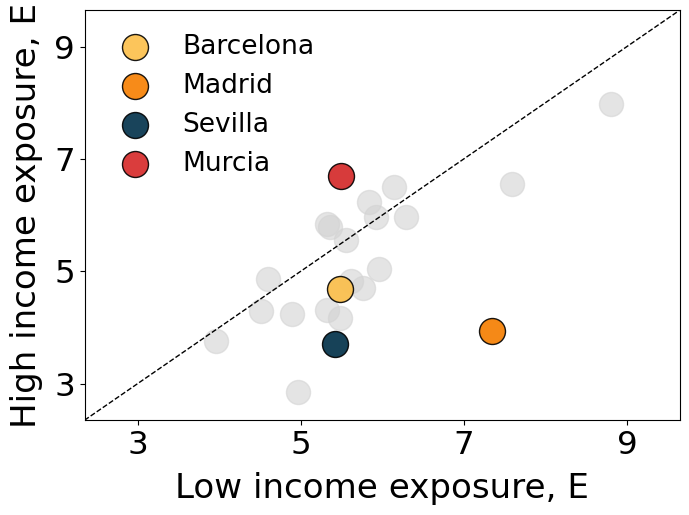

In [77]:
filtered = df_results[
    df_results['income'].isin(['<10', '>15'])
]

df_scatter = filtered.pivot(index='city', columns='income', values='E_T')

big_cities = ['Barcelona', 'Madrid', 'Sevilla', 'Murcia']
big_colors = {
    'Barcelona': '#FCBF49',
    'Madrid':    '#F77F00',
    'Sevilla':   '#003049',
    'Murcia':  '#D62828'
}

fig, ax = plt.subplots(figsize=(7, 5.25))

ax.scatter(df_scatter['<10'], df_scatter['>15'],
           color='lightgrey', alpha=0.6, s=300, label='_nolegend_')

for city in big_cities:
    x, y = df_scatter.loc[city, '<10'], df_scatter.loc[city, '>15']
    ax.scatter(x, y,
               color=big_colors[city],
               edgecolor='black',
               s=350,
               alpha=0.9,
               label=city)


lims = [2.35, 9.65]
ax.plot(lims, lims, 'k--', linewidth=1)

ax.set_xlabel('Low income exposure, E', fontsize=24.5, labelpad=8) 
ax.set_ylabel('High income exposure, E', fontsize=24.5, labelpad=8) 
ax.set_xticks([3, 5, 7, 9])
ax.set_yticks([3, 5, 7, 9])
plt.tick_params(axis='x', labelsize=23.5)
plt.tick_params(axis='y', labelsize=23.5)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.legend(fontsize=19, frameon=False)
plt.tight_layout()
plt.savefig('high_vs_low_income_exposure_'+DATE+'.svg', format='svg', dpi=600, bbox_inches='tight')
plt.show()

In [78]:
pivot = (df_results
         .pivot(index='city', columns='income', values='E_T')
         [['<10','>15']]                       
         .dropna())                            

signed_gap = pivot['<10'] - pivot['>15']

abs_gap    = signed_gap.abs()

rel_gap    = pivot['<10'] / pivot['>15']

df_plot_income = (pd.DataFrame({
              'city'        : pivot.index,
              'dE_signed' : signed_gap.round(3),
              'dE'    : abs_gap.round(3),
              'rel_gap'     : rel_gap.round(3)
          })
          .reset_index(drop=True))

In [79]:
df_plot_income

,city,dE_signed,dE,rel_gap
0,A_Coruna,-0.259,0.259,0.947
1,Alicante,1.004,1.004,1.233
2,Barcelona,0.809,0.809,1.173
3,Bilbao,-0.047,0.047,0.992
4,Cartagena,0.656,0.656,1.155
5,Cordoba,1.063,1.063,1.226
6,Elche,2.111,2.111,1.741
7,Gijon,-0.422,0.422,0.927
8,Granada,0.914,0.914,1.181
9,Jerez_de_la_Frontera,1.316,1.316,1.316


# AGE


Processing Madrid


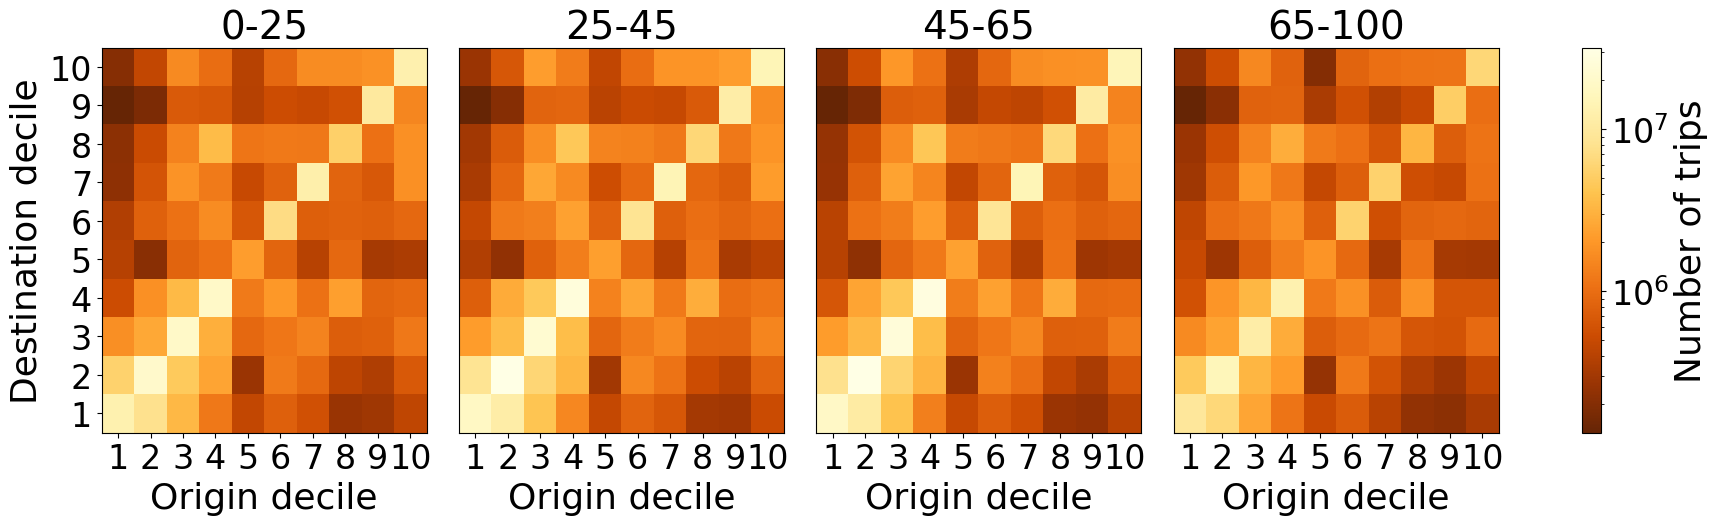

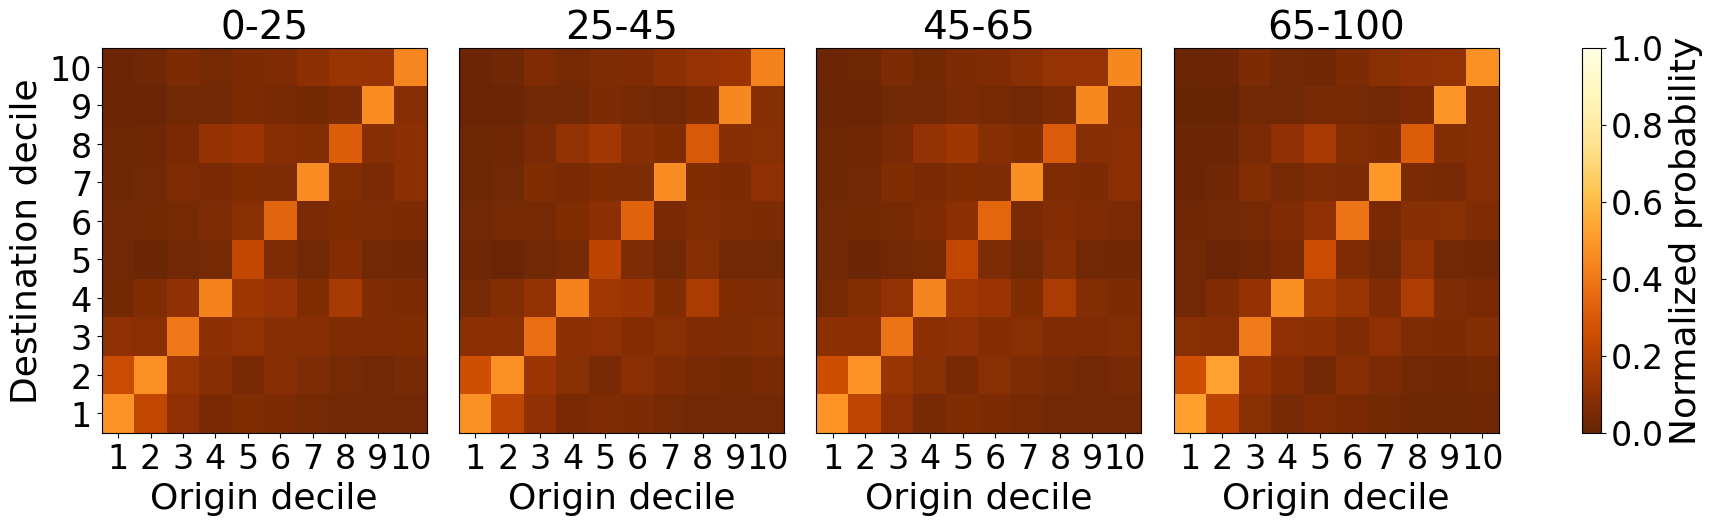


Processing Barcelona

Processing Valencia

Processing Zaragoza

Processing Sevilla

Processing Malaga

Processing Murcia

Processing Palma_de_Mallorca

Processing Las_Palmas

Processing Alicante

Processing Bilbao

Processing Valladolid

Processing Cordoba

Processing Vigo

Processing Gijon

Processing Vitoria_Gasteiz

Processing A_Coruna

Processing Granada

Processing Elche

Processing Cartagena

Processing Oviedo

Processing Jerez_de_la_Frontera

Processing Santa_Cruz_de_Tenerife


In [108]:
age_groups = ['0-25', '25-45', '45-65', '65-100']
all_bins   = list(range(1, n_bins+1))

X_T_all = {
    age: pd.DataFrame(
        0,
        index=all_bins,
        columns=all_bins,
        dtype=float
    )
    for age in age_groups
}

title_fs     = 28
label_fs     = 26
ticklabel_fs = 24

results = []

for city in cities:
    print(f"\n{'='*34}\nProcessing {city}")

    vmax = 0

    ddf      = results_districts[city]
    mapper_T = ddf.set_index('ID')['Tbin'].to_dict()

    df_city = mobs[city].copy()
    if 'Tbin_origin' not in df_city.columns:
        df_city['Tbin_origin'] = df_city['origen'].map(mapper_T).astype('Int8')
        df_city['Tbin_dest']   = df_city['destino'].map(mapper_T).astype('Int8')

    figA, axesA = plt.subplots(
        1, len(age_groups),
        figsize=(5 * len(age_groups), 5),
        sharex=False, sharey=False
    )
    axesA = np.atleast_1d(axesA)

    for i, age in enumerate(age_groups):
        g = df_city[df_city['edad'] == age]

        X_T = (g.groupby(['Tbin_origin','Tbin_dest'])['viajes']
                 .sum().unstack(fill_value=0)
                 .reindex(index=all_bins, columns=all_bins, fill_value=0))

        total = X_T.values.sum()
        X_Tn  = X_T / total if total else X_T

        vmax = max(vmax, X_T.values.max())
        # print(X_T.values.max())

    for i, age in enumerate(age_groups):
        g = df_city[df_city['edad'] == age]

        X_T = (g.groupby(['Tbin_origin','Tbin_dest'])['viajes']
                 .sum().unstack(fill_value=0)
                 .reindex(index=all_bins, columns=all_bins, fill_value=0))

        X_T_all[age] += X_T

        total = X_T.values.sum()
        X_Tn  = X_T / total if total else X_T

        rho_T    = rho_assortativity(X_Tn.values)
        E_T      = total_exposure(X_T)
        R_T      = exposure_directional_index(X_T)
        R_T_row  = exposure_directional_index_row(X_T)
        results.append({
            'city': city, 'age': age,
            'rho_T': rho_T, 'E_T': E_T,
            'R_T': R_T, 'R_T_row': R_T_row
        })

        X_plot = X_T.copy()
        positive_vals = X_plot.values[X_plot.values > 0]

        if len(positive_vals) > 0:
            vmin_log = positive_vals.min()
        else:
            vmin_log = 1.0

        im = axesA[i].imshow(
            X_plot.T,
            origin='lower',
            aspect='auto',
            cmap='YlOrBr_r',
            norm=LogNorm(vmin=vmin_log, vmax=vmax)) 
        
        axesA[i].set_title(age, fontsize=title_fs)
        axesA[i].set_xlabel("Origin decile", fontsize=label_fs)
        axesA[i].set_xticks(np.arange(n_bins))
        axesA[i].set_xticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
        axesA[i].tick_params(axis='x', labelbottom=True, labelsize=ticklabel_fs)

        if i == 0:
            axesA[i].set_ylabel("Destination decile", fontsize=label_fs)
            axesA[i].set_yticks(np.arange(n_bins))
            axesA[i].set_yticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
            axesA[i].tick_params(axis='y', labelleft=True, labelsize=ticklabel_fs)
        else:
            axesA[i].set_ylabel("")
            axesA[i].set_yticks([])
            axesA[i].set_yticklabels([])
            axesA[i].tick_params(axis='y', left=False, labelleft=False)

    figA.subplots_adjust(wspace=0.1, right=0.88)
    cbarA = figA.colorbar(
        im, ax=axesA.tolist(),
        orientation='vertical',
        fraction=0.02, pad=0.055
    )
    cbarA.ax.tick_params(labelsize=ticklabel_fs)
    cbarA.set_label("Number of trips", fontsize=label_fs)
    cbarA.ax.yaxis.get_offset_text().set_fontsize(21)

    if city in ['Madrid']:
        figA.savefig(f'{city}_OD_age_T_total_{DATE}.svg',
                     dpi=600, bbox_inches='tight')
        plt.show(figA)
    plt.close(figA)

    figB, axesB = plt.subplots(
        1, len(age_groups),
        figsize=(5 * len(age_groups), 5),
        sharex=False, sharey=False
    )
    axesB = np.atleast_1d(axesB)

    for i, age in enumerate(age_groups):
        g = df_city[df_city['edad'] == age]

        X_T = (g.groupby(['Tbin_origin','Tbin_dest'])['viajes']
                 .sum().unstack(fill_value=0)
                 .reindex(index=all_bins, columns=all_bins, fill_value=0))

        row_sums = X_T.sum(axis=1).replace(0, 1)
        X_Trow   = X_T.div(row_sums, axis=0)

        im = axesB[i].imshow(
            X_Trow.T,
            origin='lower', aspect='auto',
            cmap='YlOrBr_r', vmin=0, vmax=1.0
        )
        axesB[i].set_title(age, fontsize=title_fs)
        axesB[i].set_xlabel("Origin decile", fontsize=label_fs)
        axesB[i].set_xticks(np.arange(n_bins))
        axesB[i].set_xticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
        axesB[i].tick_params(axis='x', labelbottom=True, labelsize=ticklabel_fs)

        if i == 0:
            axesB[i].set_ylabel("Destination decile", fontsize=label_fs)
            axesB[i].set_yticks(np.arange(n_bins))
            axesB[i].set_yticklabels(np.arange(1, n_bins+1), fontsize=ticklabel_fs)
            axesB[i].tick_params(axis='y', labelleft=True, labelsize=ticklabel_fs)
        else:
            axesB[i].set_ylabel("")
            axesB[i].set_yticks([])
            axesB[i].set_yticklabels([])
            axesB[i].tick_params(axis='y', left=False, labelleft=False)

    figB.subplots_adjust(wspace=0.1, right=0.88)
    cbarB = figB.colorbar(
        im, ax=axesB.tolist(),
        orientation='vertical',
        fraction=0.02, pad=0.055
    )
    cbarB.ax.tick_params(labelsize=ticklabel_fs)
    cbarB.set_label("Normalized probability", fontsize=label_fs)
    cbarB.ax.yaxis.get_offset_text().set_fontsize(21)

    if city in ['Madrid']:
        figB.savefig(f'{city}_OD_age_T_rownorm_{DATE}.svg',
                     dpi=600, bbox_inches='tight')
        plt.show(figB)
    plt.close(figB)

df_results = pd.DataFrame(results)

In [109]:
df_results

,city,age,rho_T,E_T,R_T,R_T_row
0,Madrid,0-25,0.576,4.991,-0.048,-0.087
1,Madrid,25-45,0.567,4.901,-0.026,-0.083
2,Madrid,45-65,0.573,4.878,-0.027,-0.093
3,Madrid,65-100,0.606,4.660,0.008,-0.105
4,Barcelona,0-25,0.335,5.391,0.010,-0.008
...,...,...,...,...,...,...
87,Jerez_de_la_Frontera,65-100,0.701,4.597,0.028,-0.212
88,Santa_Cruz_de_Tenerife,0-25,0.369,6.937,-0.041,0.184
89,Santa_Cruz_de_Tenerife,25-45,0.345,6.916,-0.024,0.185
90,Santa_Cruz_de_Tenerife,45-65,0.351,6.834,-0.007,0.181


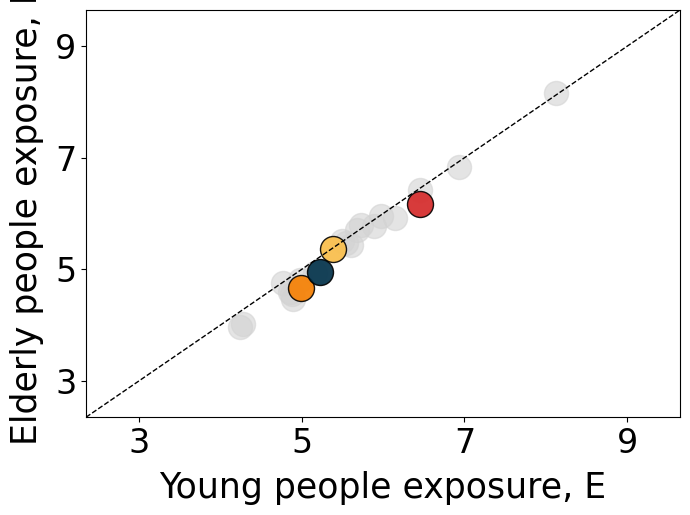

In [110]:
filtered = df_results[
    df_results['age'].isin(['0-25', '65-100'])]

df_scatter = filtered.pivot(index='city', columns='age', values='E_T')

big_cities = ['Barcelona', 'Madrid', 'Murcia', 'Sevilla']
big_colors = {
    'Barcelona': '#FCBF49',
    'Madrid':    '#F77F00',
    'Murcia':  '#D62828',
    'Sevilla':   '#003049'
}

fig, ax = plt.subplots(figsize=(7, 5.25))

ax.scatter(df_scatter['0-25'], df_scatter['65-100'],
           color='lightgrey', alpha=0.6, s=300, label='_nolegend_')

for city in big_cities:
    x, y = df_scatter.loc[city, '0-25'], df_scatter.loc[city, '65-100']
    ax.scatter(x, y,
               color=big_colors[city],
               edgecolor='black',
               s=350,
               alpha=0.9,
               label=city)

lims = [2.35, 9.65]
ax.plot(lims, lims, 'k--', linewidth=1)

ax.set_xlabel('Young people exposure, E', fontsize=25, labelpad=8)
ax.set_ylabel('Elderly people exposure, E', fontsize=25, labelpad=8)
ax.set_xticks([3, 5, 7, 9])
ax.set_yticks([3, 5, 7, 9])
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.savefig('young_vs_elderly_exposure_'+DATE+'.svg', format='svg', dpi=600, bbox_inches='tight')
plt.show()

In [111]:
pivot = (df_results
         .pivot(index='city', columns='age', values='E_T')
         [['0-25','65-100']]                     
         .dropna())                           


signed_gap = pivot['0-25'] - pivot['65-100']

abs_gap    = signed_gap.abs()

rel_gap    = pivot['0-25'] / pivot['65-100']

df_plot_age = (pd.DataFrame({
              'city'        : pivot.index,
              'dE_signed' : signed_gap.round(3),
              'dE'    : abs_gap.round(3),
              'rel_gap'     : rel_gap.round(3)
          })
          .reset_index(drop=True))

In [112]:
df_plot_age

,city,dE_signed,dE,rel_gap
0,A_Coruna,0.229,0.229,1.046
1,Alicante,0.111,0.111,1.019
2,Barcelona,0.025,0.025,1.005
3,Bilbao,-0.061,0.061,0.989
4,Cartagena,0.327,0.327,1.072
5,Cordoba,0.165,0.165,1.034
6,Elche,0.411,0.411,1.092
7,Gijon,-0.011,0.011,0.998
8,Granada,0.159,0.159,1.029
9,Jerez_de_la_Frontera,0.260,0.260,1.057


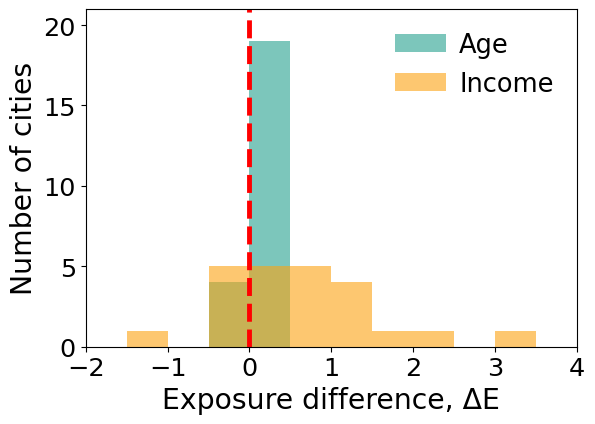

In [113]:
df_income = df_plot_income.copy()
df_age    = df_plot_age.copy()

eps = 6.5e-2
df_income['dE_signed'] = df_income['dE_signed'] + eps

min_signed = int(np.floor(min(df_income['dE_signed'].min(),
                              df_age['dE_signed'].min())))
max_signed = int(np.ceil(max(df_income['dE_signed'].max(),
                             df_age['dE_signed'].max())))
bins_signed = np.arange(min_signed-1, max_signed+1, 0.5)

orange = '#fca311'   # income
blue   = '#25a18e'   # age

fig, ax = plt.subplots(figsize=(6.05, 4.35))

ax.hist(
    df_age['dE_signed'],
    bins=bins_signed,
    color=blue,
    edgecolor='none',
    alpha=0.6,
    label='Age'
)

ax.hist(
    df_income['dE_signed'],
    bins=bins_signed,
    color=orange,
    edgecolor='none',
    alpha=0.6,
    label='Income'
)


ax.axvline(0, ls='--', lw=3.5, c='red')

ax.set_xlabel('Exposure difference, ΔE', fontsize=20.4)
ax.set_ylabel('Number of cities', fontsize=20.4)
ax.set_ylim(0, 21)
ax.set_xlim(min_signed, max_signed)

ax.tick_params(axis='both', which='major', labelsize=18.4)
ax.legend(fontsize=18.5, frameon=False, labelspacing=0.5, handletextpad=0.5)

plt.tight_layout()

plt.savefig('age_income_dE_signed_histogram_' + DATE + '.svg',
            dpi=300, bbox_inches='tight')
plt.show()

## INCOME + AGE

In [114]:
n_bins        = 10
income_groups = ['<10', '10-15', '>15']
age_groups    = ['0-25', '25-45', '45-65', '65-100']
all_bins      = range(1, n_bins+1)

X_T_all   = {(inc, age): pd.DataFrame(0, index=all_bins, columns=all_bins, dtype='float64')
             for inc in income_groups for age in age_groups}

results = []

for city in mobs.keys():                     # mobs == dict of OD tables
    print(f"\n{'='*32}\nProcessing {city}")

    ddf = results_districts[city]
    mapper_T  = ddf.set_index('ID')['Tbin' ].to_dict()

    df_city = mobs[city].copy()

    for col_o, col_d, mapper in [
        ('Tbin_origin',  'Tbin_dest',  mapper_T)
    ]:
        if col_o not in df_city:
            df_city[col_o] = df_city['origen' ].map(mapper).astype('Int8')
        if col_d not in df_city:
            df_city[col_d] = df_city['destino'].map(mapper).astype('Int8')

    df_city = df_city.dropna(subset=['Tbin_origin','Tbin_dest'])

    '''
    fig_T,   axT_grid  = plt.subplots(len(income_groups), len(age_groups),
                                      figsize=(4.5*len(age_groups), 4.0*len(income_groups)),
                                      squeeze=False)
    '''
    for r, inc in enumerate(income_groups):
        for c, age in enumerate(age_groups):

            g = df_city[(df_city['renta'] == inc) & (df_city['edad'] == age)]

            X_T = (g.groupby(['Tbin_origin','Tbin_dest'])['viajes']
                     .sum()
                     .unstack(fill_value=0)
                     .reindex(index=all_bins, columns=all_bins, fill_value=0))
            X_T_all[(inc, age)] += X_T
            X_Tn = X_T / X_T.values.sum() if X_T.values.sum() else X_T

            rho_T   = rho_assortativity(X_Tn.values)
            E_T     = total_exposure(X_T)
            R_T   = exposure_directional_index(X_T)
            R_T_row = exposure_directional_index_row(X_T)

            axT = axT_grid[r, c]
            imT = axT.imshow(X_Tn.T, origin='lower', cmap='YlOrBr_r',
                             vmin=0, vmax=0.20, aspect='auto',
                             extent=[0.5, n_bins+0.5, 0.5, n_bins+0.5])
            axT.set_title(f'{inc}, {age}', fontsize=14)
            axT.set_xticks(np.arange(n_bins))
            axT.set_yticks(np.arange(n_bins))
            axT.set_xticklabels(np.arange(1, n_bins+1), fontsize=14)
            axT.set_yticklabels(np.arange(1, n_bins+1), fontsize=14)
            axT.set_xlabel("Origin", fontsize=18)
            axT.set_ylabel("Destination", fontsize=18)

            results.append({
            'city': city,
            'income': inc,
            'age': age,
            'rho_T': rho_T,
            'E_T': E_T,
            'R_T': R_T,
            'R_T_row': R_T_row,
        })

    '''
    for fig, im in [(fig_T, imT)]:
        fig.subplots_adjust(bottom=0.08, left=0.05, right=0.95, top=0.92,
                            wspace=0.25, hspace=0.30)
        cax = fig.add_axes([0.25, 0.03, 0.50, 0.02])
        fig.colorbar(im, cax=cax, orientation='horizontal',
                     label='Share of trips')

    fig_T.suptitle(f'{city} – Temperature deciles (Income × Age)', fontsize=13)
    plt.show()
    plt.close(fig_T)
    '''

df_results = pd.DataFrame(results)


Processing Madrid

Processing Barcelona

Processing Valencia

Processing Zaragoza

Processing Sevilla

Processing Malaga

Processing Murcia

Processing Palma_de_Mallorca

Processing Las_Palmas

Processing Alicante

Processing Bilbao

Processing Valladolid

Processing Cordoba

Processing Vigo

Processing Gijon

Processing Vitoria_Gasteiz

Processing A_Coruna

Processing Granada

Processing Elche

Processing Cartagena

Processing Oviedo

Processing Jerez_de_la_Frontera

Processing Santa_Cruz_de_Tenerife


In [115]:
df_results

,city,income,age,rho_T,E_T,R_T,R_T_row
0,Madrid,<10,0-25,0.524,7.347,-0.167,0.117
1,Madrid,<10,25-45,0.515,7.291,-0.156,0.115
2,Madrid,<10,45-65,0.547,7.240,-0.157,0.090
3,Madrid,<10,65-100,0.612,7.649,-0.128,0.082
4,Madrid,10-15,0-25,0.506,5.467,-0.062,-0.032
...,...,...,...,...,...,...,...
271,Santa_Cruz_de_Tenerife,10-15,65-100,0.381,6.670,0.005,0.172
272,Santa_Cruz_de_Tenerife,>15,0-25,0.152,6.590,0.069,0.169
273,Santa_Cruz_de_Tenerife,>15,25-45,0.163,6.621,0.092,0.167
274,Santa_Cruz_de_Tenerife,>15,45-65,0.152,6.552,0.087,0.159


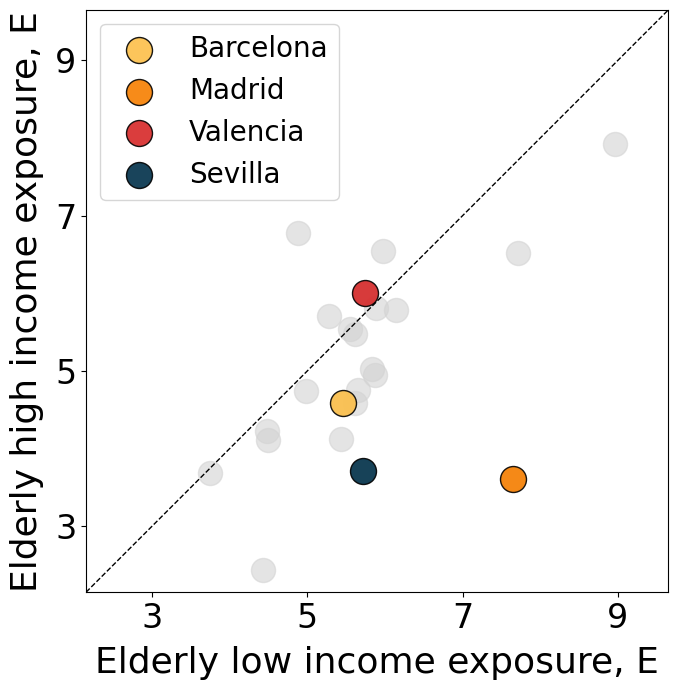

In [116]:
filtered = df_results[
    (df_results['age'] == '65-100') &
    (df_results['income'].isin(['<10', '>15']))
]

df_scatter = filtered.pivot(index='city', columns='income', values='E_T')

big_cities = ['Barcelona', 'Madrid', 'Valencia', 'Sevilla']
big_colors = {
    'Barcelona':'#FCBF49',
    'Madrid':   '#F77F00',
    'Valencia': '#D62828',
    'Sevilla':  '#003049'
}

fig, ax = plt.subplots(figsize=(7.25, 7.))

ax.scatter(df_scatter['<10'], df_scatter['>15'],
           color='lightgrey', alpha=0.6, s=300, label='_nolegend_')

for city in big_cities:
    if city not in df_scatter.index:
        continue
    x = df_scatter.loc[city, '<10']
    y = df_scatter.loc[city, '>15']
    ax.scatter(x, y,
               color=big_colors[city],
               edgecolor='black',
               alpha=0.9,
               s=350,
               label=city)

lims = [2.15, 9.65]
ax.plot(lims, lims, 'k--', linewidth=1)

ax.set_xlabel('Elderly low income exposure, E', fontsize=26, labelpad=8)
ax.set_ylabel('Elderly high income exposure, E', fontsize=26, labelpad=8)
ax.set_xticks([3, 5, 7, 9])
ax.set_yticks([3, 5, 7, 9])
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
ax.set_aspect('equal', 'box')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend(fontsize=20)

plt.tight_layout()
plt.savefig('elderly_high_vs_low_income_exposure_'+DATE+'.svg',
            format='svg', dpi=600, bbox_inches='tight')
plt.show()

In [117]:
city_pop_list = []
for city, ddf in results_districts.items():
    city_pop_list.append({
        'city': city,
        'city_pop': ddf['population'].sum()
    })

df_city_pop = pd.DataFrame(city_pop_list)

In [118]:
df_w = (
    df_results
      .merge(df_city_pop, on='city', how='left')
)

def weighted_stats(group):
    w = group['city_pop'].values
    x = group['E_T'].values

    w_sum = w.sum()
    if w_sum == 0 or len(x) == 0:
        return pd.Series({'E_T_mean_w': np.nan, 'E_T_se_w': np.nan})

    # weighted mean
    w_mean = np.average(x, weights=w)

    # weighted variance
    w_var = (w * (x - w_mean)**2).sum() / w_sum
    w_sd  = np.sqrt(w_var)

    # effective sample size for SE of weighted mean
    n_eff = (w_sum**2) / ( (w**2).sum() )
    w_se  = w_sd / np.sqrt(n_eff)

    return pd.Series({'E_T_mean_w': w_mean, 'E_T_se_w': w_se})

df_weighted = (
    df_w
      .groupby(['income', 'age'], as_index=False)
      .apply(weighted_stats)
)

C:\Users\mduran\AppData\Local\Temp\ipykernel_26092\4167301855.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_stats)


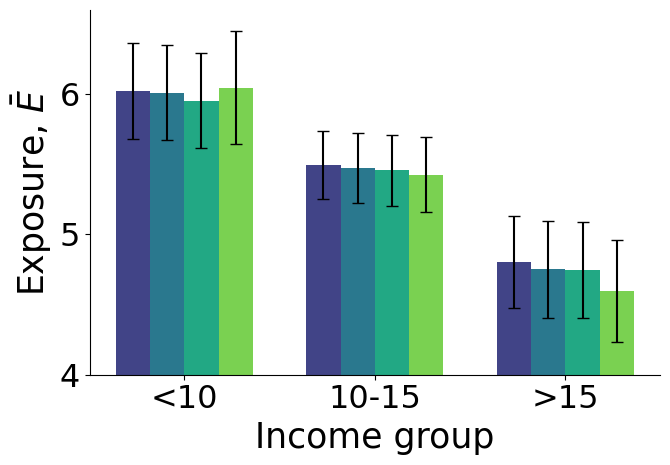

In [119]:
income_order = ['<10', '10-15', '>15']
age_order    = ['0-25', '25-45', '45-65', '65-100']
palette_age  = sns.color_palette('viridis', len(age_order))

exp_mean = (
    df_weighted
      .pivot(index='income', columns='age', values='E_T_mean_w')
      .reindex(index=income_order, columns=age_order)
)

exp_se = (
    df_weighted
      .pivot(index='income', columns='age', values='E_T_se_w')
      .reindex(index=income_order, columns=age_order)
)

fig, ax = plt.subplots(figsize=(6.8,5)) #8,3.8

bar_width = 0.18
x = np.arange(len(income_order))

for j, age in enumerate(age_order):
    ax.bar(
        x + j*bar_width,
        exp_mean[age].values,
        yerr=exp_se[age].values,      # SE of population-weighted mean
        capsize=4,
        width=bar_width,
        color=palette_age[j],
        label=age
    )

handles, labels = ax.get_legend_handles_labels()

ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(income_order, fontsize=23.)

ax.set_ylim(4, 6.6)
ax.set_yticks([4, 5, 6])
ax.tick_params(axis='y', labelsize=23.) 

ax.set_ylabel(r'Exposure, $\bar{E}$', fontsize=25.)
ax.set_xlabel('Income group', fontsize=25.)
sns.despine()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Age_income_exposure_popweighted_'+DATE+'.svg',
            format='svg', dpi=600, bbox_inches='tight')
plt.show()
